#**STUDENTS FINAL EXAM MARKS PREDICTOR**

In [21]:
import pandas as pd

In [22]:
df = pd.read_csv("../data/students_data.csv")

#**EXPLORATORY DATA ANALYSIS**

In [23]:
df.head()

,student_id,age,gender,course,year,study_hours_per_day,attendance_percent,previous_semester_marks,assignment_score,internal_marks,sleep_hours_per_day,screen_time_hours_per_day,social_media_hours_per_day,practice_tests_completed,extracurricular_level,internet_access,parent_education,scholarship,part_time_job,final_exam_marks
0,STU100001,23,Other,Information Technology,3rd,4.7,71.6,82.6,100.0,75.3,8.4,5.9,1.7,2,Medium,Good,Graduate,No,No,88.7
1,STU100002,20,Female,Mechanical Engineering,4th,6.1,74.8,66.4,59.0,59.6,6.2,6.9,3.4,5,Medium,Good,Postgraduate,No,No,69.4
2,STU100003,21,Male,Mechanical Engineering,4th,4.5,81.6,86.6,87.2,63.8,5.9,2.3,3.4,4,Medium,Average,Postgraduate,No,No,81.7
3,STU100004,23,Female,Data Science,4th,4.2,59.9,62.2,NaN,70.1,6.7,6.9,1.2,6,Medium,Good,Postgraduate,No,No,80.6
4,STU100005,19,Male,Computer Engineering,3rd,3.3,84.1,64.1,66.2,66.1,7.3,2.1,0.0,2,Low,Average,Diploma,Yes,Yes,71.7


In [24]:
df.shape

(10010, 20)

In [25]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'study_hours_per_day',
       'attendance_percent', 'previous_semester_marks', 'assignment_score',
       'internal_marks', 'sleep_hours_per_day', 'screen_time_hours_per_day',
       'social_media_hours_per_day', 'practice_tests_completed',
       'extracurricular_level', 'internet_access', 'parent_education',
       'scholarship', 'part_time_job', 'final_exam_marks'],
      dtype='str')

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10010 non-null  str    
 1   age                         10010 non-null  int64  
 2   gender                      10010 non-null  str    
 3   course                      10010 non-null  str    
 4   year                        10010 non-null  str    
 5   study_hours_per_day         9860 non-null   float64
 6   attendance_percent          9859 non-null   float64
 7   previous_semester_marks     10010 non-null  float64
 8   assignment_score            9860 non-null   float64
 9   internal_marks              10010 non-null  float64
 10  sleep_hours_per_day         9860 non-null   float64
 11  screen_time_hours_per_day   10010 non-null  float64
 12  social_media_hours_per_day  10010 non-null  float64
 13  practice_tests_completed    10010 non-null

In [27]:
df.dtypes

student_id                        str
age                             int64
gender                            str
course                            str
year                              str
study_hours_per_day           float64
attendance_percent            float64
previous_semester_marks       float64
assignment_score              float64
internal_marks                float64
sleep_hours_per_day           float64
screen_time_hours_per_day     float64
social_media_hours_per_day    float64
practice_tests_completed        int64
extracurricular_level             str
internet_access                   str
parent_education                  str
scholarship                       str
part_time_job                     str
final_exam_marks              float64
dtype: object

In [28]:
df.isnull().sum()/df.shape[0]*100

student_id                    0.000000
age                           0.000000
gender                        0.000000
course                        0.000000
year                          0.000000
study_hours_per_day           1.498501
attendance_percent            1.508492
previous_semester_marks       0.000000
assignment_score              1.498501
internal_marks                0.000000
sleep_hours_per_day           1.498501
screen_time_hours_per_day     0.000000
social_media_hours_per_day    0.000000
practice_tests_completed      0.000000
extracurricular_level         0.000000
internet_access               1.498501
parent_education              1.498501
scholarship                   0.000000
part_time_job                 0.000000
final_exam_marks              0.000000
dtype: float64

In [29]:
df.isnull().sum()

student_id                      0
age                             0
gender                          0
course                          0
year                            0
study_hours_per_day           150
attendance_percent            151
previous_semester_marks         0
assignment_score              150
internal_marks                  0
sleep_hours_per_day           150
screen_time_hours_per_day       0
social_media_hours_per_day      0
practice_tests_completed        0
extracurricular_level           0
internet_access               150
parent_education              150
scholarship                     0
part_time_job                   0
final_exam_marks                0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(10)

In [31]:
categorical_data = df.select_dtypes(include=["string","object"])
categorical_data.head()

,student_id,gender,course,year,extracurricular_level,internet_access,parent_education,scholarship,part_time_job
0,STU100001,Other,Information Technology,3rd,Medium,Good,Graduate,No,No
1,STU100002,Female,Mechanical Engineering,4th,Medium,Good,Postgraduate,No,No
2,STU100003,Male,Mechanical Engineering,4th,Medium,Average,Postgraduate,No,No
3,STU100004,Female,Data Science,4th,Medium,Good,Postgraduate,No,No
4,STU100005,Male,Computer Engineering,3rd,Low,Average,Diploma,Yes,Yes


In [32]:
numerical_data = df.select_dtypes(include=["int","float"])
numerical_data.head()

,age,study_hours_per_day,attendance_percent,previous_semester_marks,assignment_score,internal_marks,sleep_hours_per_day,screen_time_hours_per_day,social_media_hours_per_day,practice_tests_completed,final_exam_marks
0,23,4.7,71.6,82.6,100.0,75.3,8.4,5.9,1.7,2,88.7
1,20,6.1,74.8,66.4,59.0,59.6,6.2,6.9,3.4,5,69.4
2,21,4.5,81.6,86.6,87.2,63.8,5.9,2.3,3.4,4,81.7
3,23,4.2,59.9,62.2,NaN,70.1,6.7,6.9,1.2,6,80.6
4,19,3.3,84.1,64.1,66.2,66.1,7.3,2.1,0.0,2,71.7


#**DATA PREPROCESSING**

In [33]:
#Having int or float datatype
df["study_hours_per_day"] = df["study_hours_per_day"].fillna(df["study_hours_per_day"].mean())
df["attendance_percent"] = df["attendance_percent"].fillna(df["attendance_percent"].mean())
df["assignment_score"] = df["assignment_score"].fillna(df["assignment_score"].mean())
df["sleep_hours_per_day"] = df["sleep_hours_per_day"].fillna(df["sleep_hours_per_day"].mean())

#Having object datatype
df["internet_access"] = df["internet_access"].fillna(df["internet_access"].mode()[0])
df["parent_education"] = df["parent_education"].fillna(df["parent_education"].mode()[0])

In [34]:
df.shape

(10010, 20)

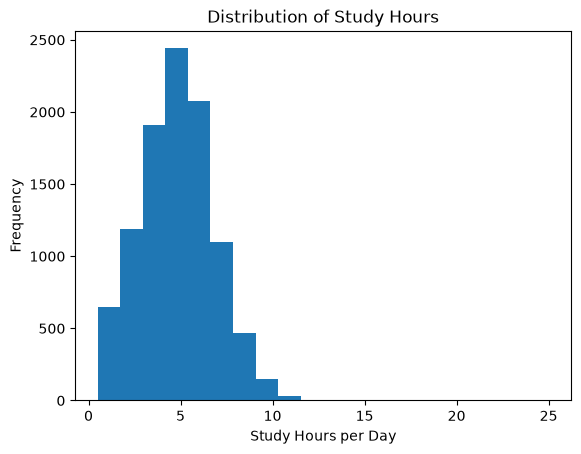

In [35]:
import matplotlib.pyplot as plt

plt.hist(df['study_hours_per_day'], bins=20)
plt.xlabel('Study Hours per Day')
plt.ylabel('Frequency')
plt.title('Distribution of Study Hours')
plt.show()

#**FEATURE ENGINEERING**

In [36]:
numerical_data = df.select_dtypes(include=["int","float"])
numerical_data.head()

,age,study_hours_per_day,attendance_percent,previous_semester_marks,assignment_score,internal_marks,sleep_hours_per_day,screen_time_hours_per_day,social_media_hours_per_day,practice_tests_completed,final_exam_marks
0,23,4.7,71.6,82.6,100.000000,75.3,8.4,5.9,1.7,2,88.7
1,20,6.1,74.8,66.4,59.000000,59.6,6.2,6.9,3.4,5,69.4
2,21,4.5,81.6,86.6,87.200000,63.8,5.9,2.3,3.4,4,81.7
3,23,4.2,59.9,62.2,72.027373,70.1,6.7,6.9,1.2,6,80.6
4,19,3.3,84.1,64.1,66.200000,66.1,7.3,2.1,0.0,2,71.7


In [37]:
categorical_data = df.select_dtypes(include=["string","object"])
categorical_data.head()

,student_id,gender,course,year,extracurricular_level,internet_access,parent_education,scholarship,part_time_job
0,STU100001,Other,Information Technology,3rd,Medium,Good,Graduate,No,No
1,STU100002,Female,Mechanical Engineering,4th,Medium,Good,Postgraduate,No,No
2,STU100003,Male,Mechanical Engineering,4th,Medium,Average,Postgraduate,No,No
3,STU100004,Female,Data Science,4th,Medium,Good,Postgraduate,No,No
4,STU100005,Male,Computer Engineering,3rd,Low,Average,Diploma,Yes,Yes


In [38]:
df = df.drop("student_id", axis=1)

In [39]:
df.shape

(10010, 19)

#**ML PIPELINE**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [ ]:
numeric_features = [
    "age",
    "study_hours_per_day",
    "attendance_percent",
    "previous_semester_marks",
    "assignment_score",
    "internal_marks",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "social_media_hours_per_day",
    "practice_tests_completed"
]


categorical_features = [
    "gender",
    "course",
    "year",
    "extracurricular_level",
    "internet_access",
    "parent_education",
    "scholarship",
    "part_time_job"
]

In [ ]:
#PREPROCESSER

preprocesser = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    ]
)

In [ ]:
#PIPELINE

model = Pipeline(
    steps=[
        ("preprocessor", preprocesser),
        ("regressor", LinearRegression())
       ]
)

#**MODEL TRAINING**

In [ ]:
X = df.drop('final_exam_marks', axis=1)
y = df['final_exam_marks']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

print("\nMAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test,y_pred))
print("R2:", r2_score(y_test,y_pred))

In [ ]:
age = int(input("Enter age: "))
gender = input("Enter gender (Male, Female, Other): ")
course = input("Enter course (e.g., Data Science, Computer Engineering): ")
study_hours_per_day = float(input("Enter study hours per day: "))
attendance_percent = float(input("Enter attendance percentage: "))
previous_semester_marks = float(input("Enter previous semester marks: "))
assignment_score = float(input("Enter assignment score: "))
internal_marks = float(input("Enter internal marks: "))
sleep_hours_per_day = float(input("Enter sleep hours per day: "))
screen_time_hours_per_day = float(input("Enter screen time per day: "))
social_media_hours_per_day = float(input("Enter social media hours per day: "))
practice_tests_completed = int(input("Enter practice tests completed: "))

year = input("Enter year (1st, 2nd, 3rd, 4th): ")
extracurricular_level = input("Enter extracurricular level (High, Low, Medium): ")
internet_access = input("Enter internet access (Average, Good, Poor): ")
parent_education = input("Enter parent education (Diploma, Graduate, Postgraduate, School): ")
scholarship = input("Scholarship (Yes/No): ")
part_time_job = input("Part-time job (Yes/No): ")

In [ ]:
import pandas as pd

# Create a dictionary of input values
input_data = {
    'age': age,
    'gender': gender,
    'course': course,
    'year': year,
    'study_hours_per_day': study_hours_per_day,
    'attendance_percent': attendance_percent,
    'previous_semester_marks': previous_semester_marks,
    'assignment_score': assignment_score,
    'internal_marks': internal_marks,
    'sleep_hours_per_day': sleep_hours_per_day,
    'screen_time_hours_per_day': screen_time_hours_per_day,
    'social_media_hours_per_day': social_media_hours_per_day,
    'practice_tests_completed': practice_tests_completed,
    'extracurricular_level': extracurricular_level,
    'internet_access': internet_access,
    'parent_education': parent_education,
    'scholarship': scholarship,
    'part_time_job': part_time_job
}


feature_columns = ['age', 'gender', 'course', 'year', 'study_hours_per_day', 'attendance_percent', 'previous_semester_marks', 'assignment_score', 'internal_marks', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'social_media_hours_per_day', 'practice_tests_completed', 'extracurricular_level', 'internet_access', 'parent_education', 'scholarship', 'part_time_job']

prediction_df = pd.DataFrame([input_data], columns=feature_columns)

prediction = model.predict(prediction_df)
print(f"Predicted Final Exam Marks: {prediction[0]:.2f}")

In [ ]:
import joblib

joblib.dump(model, 'final_exam_predictor_model.joblib')

print("Model saved as final_exam_predictor_model.joblib")

In [ ]:
print(model)

In [ ]:
print(prediction_df.T)

In [ ]:
print(prediction)

In [ ]:
import joblib

loaded_model = joblib.load(
    "final_exam_predictor_model.joblib"
)

print("Model loaded successfully!")

In [ ]:
prediction = loaded_model.predict(prediction_df)

print("Prediction:", prediction[0])

In [ ]:
import sklearn
print(sklearn.__version__)